
# PROJECT TITLE: ***Adaptive Intelligence Engine for Predicting Human Skill Evolution in Digital Platforms***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Predicting Human Skill Evolution in Digital Platforms.xlsx")

In [ ]:
df.head()

,G1,G2,G3,studytime,absences,failures,schoolsup,famsup,age,address,...,reason,internet,health,online_learning_hours,daily_study_hours,practice_sessions,screen_time_hours,learning_style,motivation_level,parent_education
0,35.0,35.0,50.0,1,5,0,no,no,13,Urban,...,reputation,yes,Poor,14.0,1.6,2,6.8,Kinesthetic,Medium,###
1,0.0,0.0,0.0,3,11,0,no,yes,14,Rural,...,other,yes,Poor,4.0,3.6,7,1.6,Visual,Medium,Graduate
2,55.0,70.0,80.0,2,3,0,no,yes,16,R,...,other,no,Good,8.0,4.6,4,4.7,Auditory,Medium,Secondary
3,75.0,70.0,60.0,4,3+,1,no,no,14,R,...,other,yes,Good,4.0,4.5,4,2.5,Kinesthetic,Low,Graduate
4,55.0,75.0,70.0,2,3+,1,yes,no,14,R,...,other,yes,Poor,7.0,2.2,5,2.5,Kinesthetic,Medium,Secondary


In [ ]:
df.shape

(10200, 21)

In [ ]:
df.columns

Index(['G1', 'G2', 'G3', 'studytime', 'absences', 'failures', 'schoolsup',
       'famsup', 'age', 'address', 'guardian', 'reason', 'internet', 'health',
       'online_learning_hours', 'daily_study_hours', 'practice_sessions',
       'screen_time_hours', 'learning_style', 'motivation_level',
       'parent_education'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   G1                     10200 non-null  float64
 1   G2                     10200 non-null  float64
 2   G3                     10200 non-null  float64
 3   studytime              9900 non-null   object 
 4   absences               9900 non-null   object 
 5   failures               9900 non-null   object 
 6   schoolsup              10200 non-null  object 
 7   famsup                 10200 non-null  object 
 8   age                    10200 non-null  int64  
 9   address                10200 non-null  object 
 10  guardian               10200 non-null  object 
 11  reason                 10200 non-null  object 
 12  internet               10200 non-null  object 
 13  health                 10200 non-null  object 
 14  online_learning_hours  9900 non-null   float64
 15  da

In [ ]:
df.describe()

,G1,G2,G3,age,online_learning_hours,daily_study_hours,practice_sessions,screen_time_hours
count,10200.000000,10200.000000,10200.000000,10200.000000,9900.000000,10200.000000,10200.000000,10200.000000
mean,47.775967,50.433014,52.491891,14.489510,7.488182,3.281902,5.024020,4.497373
std,28.895307,29.831836,29.998591,1.700455,4.031415,1.590963,2.580997,2.033585
min,-2.249923,-2.209862,-2.430634,12.000000,1.000000,0.500000,1.000000,1.000000
25%,20.887214,25.000000,30.000000,13.000000,4.000000,1.900000,3.000000,2.700000
50%,50.000000,50.000000,55.000000,14.000000,7.000000,3.300000,5.000000,4.500000
75%,75.000000,75.000000,80.000000,16.000000,11.000000,4.700000,7.000000,6.300000
max,97.291795,102.208802,102.255618,17.000000,14.000000,6.000000,9.000000,8.000000


In [ ]:
df.isnull().sum()


,0
G1,0
G2,0
G3,0
studytime,300
absences,300
failures,300
schoolsup,0
famsup,0
age,0
address,0


In [ ]:
df.duplicated().sum()

np.int64(0)

We inspected the dataset to understand its size, structure, data types, missing values, and duplicates before performing any cleaning.

In [ ]:
#data cleaning

df['absences'] = df['absences'].replace('3+', 3)

num_cols = ['studytime', 'absences', 'failures']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
df['parent_education'] = df['parent_education'].replace('###', pd.NA)

In [ ]:
for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

We cleaned the dataset by fixing incorrect data types, handling special values like ‘3+’, replacing invalid entries, and filling missing values using mean and mode.

In [ ]:
df.dtypes

,0
G1,float64
G2,float64
G3,float64
studytime,float64
absences,float64
failures,float64
schoolsup,object
famsup,object
age,int64
address,object


In [ ]:
df.columns

Index(['G1', 'G2', 'G3', 'studytime', 'absences', 'failures', 'schoolsup',
       'famsup', 'age', 'address', 'guardian', 'reason', 'internet', 'health',
       'online_learning_hours', 'daily_study_hours', 'practice_sessions',
       'screen_time_hours', 'learning_style', 'motivation_level',
       'parent_education'],
      dtype='object')

In [ ]:
df

,G1,G2,G3,studytime,absences,failures,schoolsup,famsup,age,address,...,reason,internet,health,online_learning_hours,daily_study_hours,practice_sessions,screen_time_hours,learning_style,motivation_level,parent_education
0,35.0,35.0,50.0,1.0,5.000000,0.0,no,no,13,Urban,...,reputation,yes,Poor,14.000000,1.6,2,6.8,Kinesthetic,Medium,Primary
1,0.0,0.0,0.0,3.0,11.000000,0.0,no,yes,14,Rural,...,other,yes,Poor,4.000000,3.6,7,1.6,Visual,Medium,Graduate
2,55.0,70.0,80.0,2.0,3.000000,0.0,no,yes,16,R,...,other,no,Good,8.000000,4.6,4,4.7,Auditory,Medium,Secondary
3,75.0,70.0,60.0,4.0,3.000000,1.0,no,no,14,R,...,other,yes,Good,4.000000,4.5,4,2.5,Kinesthetic,Low,Graduate
4,55.0,75.0,70.0,2.0,3.000000,1.0,yes,no,14,R,...,other,yes,Poor,7.000000,2.2,5,2.5,Kinesthetic,Medium,Secondary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,5.0,10.0,15.0,1.0,19.000000,0.0,yes,no,17,U,...,reputation,yes,Average,8.000000,6.0,9,5.1,Auditory,Low,Primary
10196,80.0,70.0,70.0,3.0,19.000000,0.0,yes,no,12,U,...,course,yes,Good,8.000000,1.5,5,4.9,Auditory,Low,Graduate
10197,85.0,85.0,95.0,3.0,2.000000,0.0,yes,yes,17,R,...,other,yes,Average,2.000000,2.5,6,1.8,Auditory,Low,Graduate
10198,15.0,5.0,20.0,2.0,9.528971,0.0,yes,no,14,U,...,reputation,yes,Good,7.488182,4.0,8,1.8,Visual,High,Secondary


In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].round(0).astype(int)

In [ ]:
df.dtypes

,0
G1,int64
G2,int64
G3,int64
studytime,int64
absences,int64
failures,int64
schoolsup,object
famsup,object
age,int64
address,object


In [ ]:
df['address'] = df['address'].replace({
    'U': 'Urban',
    'R': 'Rural'
})


In [ ]:
df

,G1,G2,G3,studytime,absences,failures,schoolsup,famsup,age,address,...,reason,internet,health,online_learning_hours,daily_study_hours,practice_sessions,screen_time_hours,learning_style,motivation_level,parent_education
0,35,35,50,1,5,0,no,no,13,Urban,...,reputation,yes,Poor,14,2,2,7,Kinesthetic,Medium,Primary
1,0,0,0,3,11,0,no,yes,14,Rural,...,other,yes,Poor,4,4,7,2,Visual,Medium,Graduate
2,55,70,80,2,3,0,no,yes,16,Rural,...,other,no,Good,8,5,4,5,Auditory,Medium,Secondary
3,75,70,60,4,3,1,no,no,14,Rural,...,other,yes,Good,4,4,4,2,Kinesthetic,Low,Graduate
4,55,75,70,2,3,1,yes,no,14,Rural,...,other,yes,Poor,7,2,5,2,Kinesthetic,Medium,Secondary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,5,10,15,1,19,0,yes,no,17,Urban,...,reputation,yes,Average,8,6,9,5,Auditory,Low,Primary
10196,80,70,70,3,19,0,yes,no,12,Urban,...,course,yes,Good,8,2,5,5,Auditory,Low,Graduate
10197,85,85,95,3,2,0,yes,yes,17,Rural,...,other,yes,Average,2,2,6,2,Auditory,Low,Graduate
10198,15,5,20,2,10,0,yes,no,14,Urban,...,reputation,yes,Good,7,4,8,2,Visual,High,Secondary


In [ ]:
df['schoolsup'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df['famsup'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df['parent_education'].unique()

array(['Primary', 'Graduate', 'Secondary', 'unknown#', '??', '@@',
       'None!'], dtype=object)

In [ ]:
df['parent_education'] = df['parent_education'].replace(
    ['unknown#', '??', '@@', 'None!'],
    'Unknown'
)


In [ ]:
df['parent_education'] = df['parent_education'].str.strip().str.title()

In [ ]:
df['parent_education'].unique()

array(['Primary', 'Graduate', 'Secondary', 'Unknown'], dtype=object)

In [ ]:
df['learning_style'] = (
    df['learning_style']
    .astype(str)
    .str.strip()
    .replace(
        ['None!', '??', '@@', '###', 'unknown#'],
        'Unknown'
    )
)


In [ ]:
df['learning_style'].unique()

array(['Kinesthetic', 'Visual', 'Auditory', 'Unknown'], dtype=object)

In [ ]:
df['motivation_level'] = (
    df['motivation_level']
    .astype(str)
    .str.strip()
    .replace(
        ['None!', '??', '@@', '###', 'unknown#'],
        'Unknown'
    )
)


In [ ]:
df['motivation_level'].unique()

array(['Medium', 'Low', 'High', 'Unknown'], dtype=object)

In [ ]:
#Create failures from grades
df['failures'] = (df['G3'] < 50).astype(int)
df

,G1,G2,G3,studytime,absences,failures,schoolsup,famsup,age,address,...,reason,internet,health,online_learning_hours,daily_study_hours,practice_sessions,screen_time_hours,learning_style,motivation_level,parent_education
0,35,35,50,1,5,0,no,no,13,Urban,...,reputation,yes,Poor,14,2,2,7,Kinesthetic,Medium,Primary
1,0,0,0,3,11,1,no,yes,14,Rural,...,other,yes,Poor,4,4,7,2,Visual,Medium,Graduate
2,55,70,80,2,3,0,no,yes,16,Rural,...,other,no,Good,8,5,4,5,Auditory,Medium,Secondary
3,75,70,60,4,3,0,no,no,14,Rural,...,other,yes,Good,4,4,4,2,Kinesthetic,Low,Graduate
4,55,75,70,2,3,0,yes,no,14,Rural,...,other,yes,Poor,7,2,5,2,Kinesthetic,Medium,Secondary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,5,10,15,1,19,1,yes,no,17,Urban,...,reputation,yes,Average,8,6,9,5,Auditory,Low,Primary
10196,80,70,70,3,19,0,yes,no,12,Urban,...,course,yes,Good,8,2,5,5,Auditory,Low,Graduate
10197,85,85,95,3,2,0,yes,yes,17,Rural,...,other,yes,Average,2,2,6,2,Auditory,Low,Graduate
10198,15,5,20,2,10,1,yes,no,14,Urban,...,reputation,yes,Good,7,4,8,2,Visual,High,Secondary


In [ ]:
df.dtypes

,0
G1,int64
G2,int64
G3,int64
studytime,int64
absences,int64
failures,int64
schoolsup,object
famsup,object
age,int64
address,object


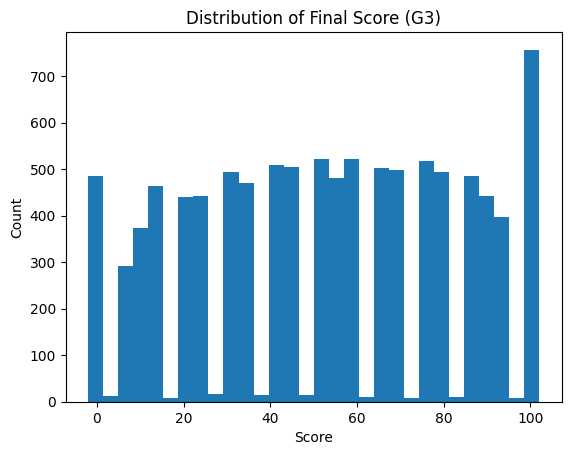

In [ ]:
#EDA – Exploratory Data Analysis

#Distribution of Final Score (G3)
import matplotlib.pyplot as plt

plt.hist(df['G3'], bins=30)
plt.title("Distribution of Final Score (G3)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

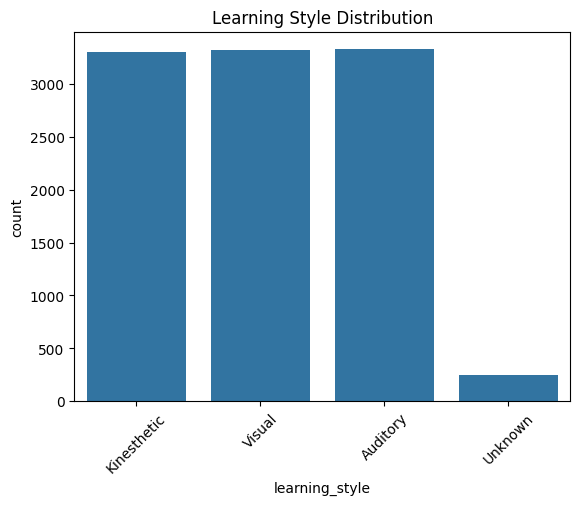

In [ ]:
#Learning Style Count
import seaborn as sns

sns.countplot(x='learning_style', data=df)
plt.xticks(rotation=45)
plt.title("Learning Style Distribution")
plt.show()

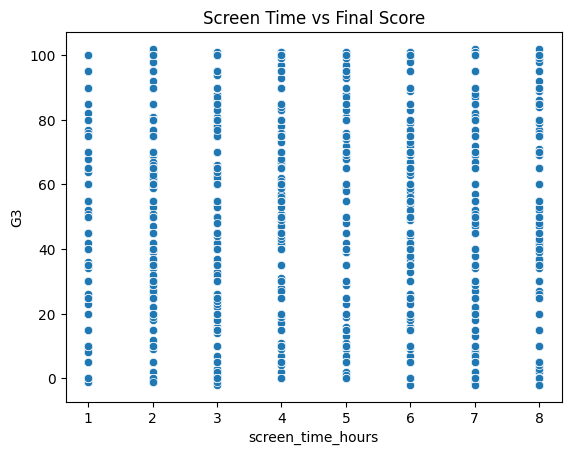

In [ ]:
#Screen Time vs Final Score

sns.scatterplot(x='screen_time_hours', y='G3', data=df)
plt.title("Screen Time vs Final Score")
plt.show()

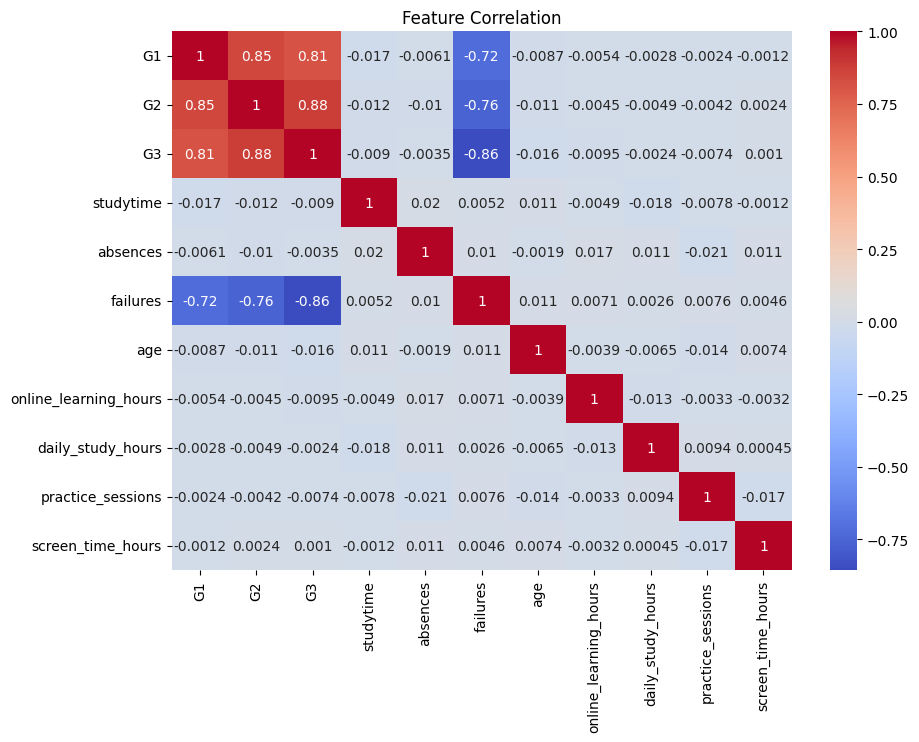

In [ ]:
#Correlation Heatmap

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

<Figure size 640x480 with 0 Axes>

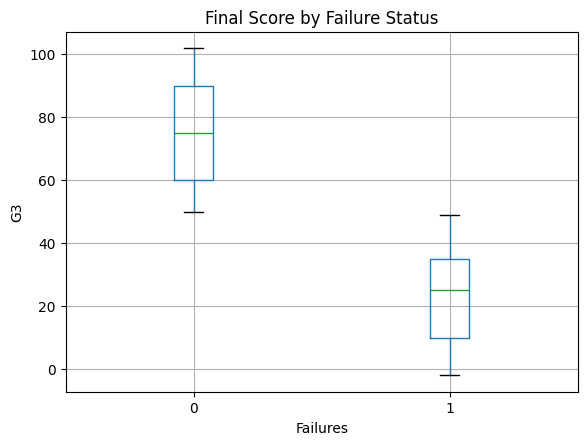

In [ ]:
#Grades vs Failure
plt.figure()
df.boxplot(column='G3', by='failures')
plt.title('Final Score by Failure Status')
plt.suptitle('')
plt.xlabel('Failures')
plt.ylabel('G3')
plt.show()

<Figure size 640x480 with 0 Axes>

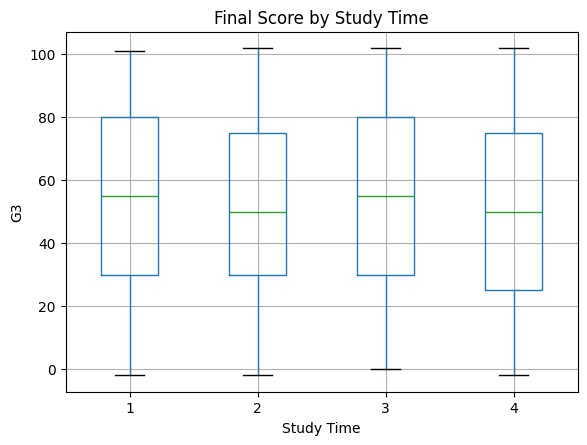

In [ ]:
#Study Time vs Final Score
plt.figure()
df.boxplot(column='G3', by='studytime')
plt.title('Final Score by Study Time')
plt.suptitle('')
plt.xlabel('Study Time')
plt.ylabel('G3')
plt.show()


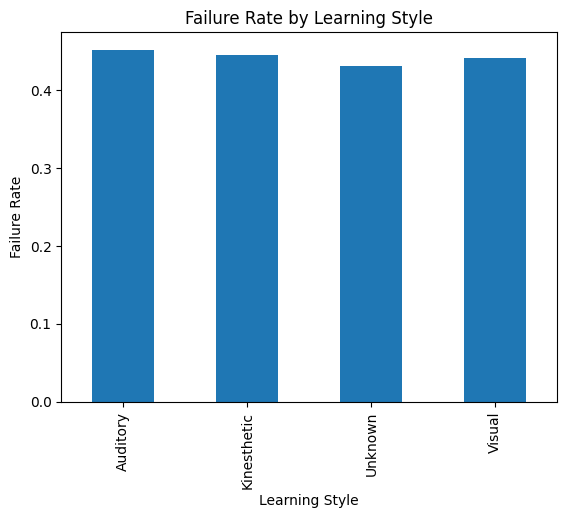

In [ ]:
#Failure Rate by Learning Style
failure_rate = df.groupby('learning_style')['failures'].mean()
plt.figure()
failure_rate.plot(kind='bar')
plt.title('Failure Rate by Learning Style')
plt.ylabel('Failure Rate')
plt.xlabel('Learning Style')
plt.show()


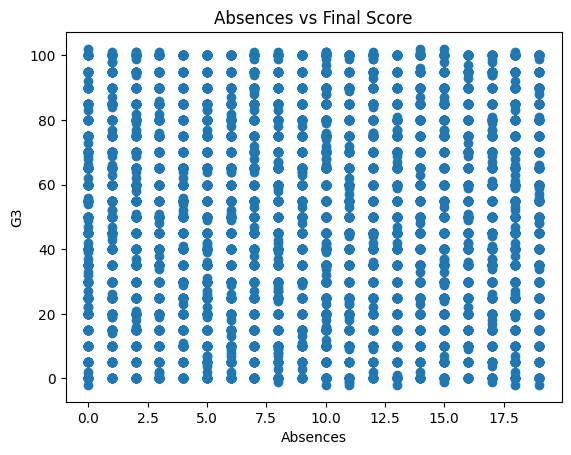

In [ ]:
#Absences vs Final Score (Scatter)
plt.figure()
plt.scatter(df['absences'], df['G3'])
plt.title('Absences vs Final Score')
plt.xlabel('Absences')
plt.ylabel('G3')
plt.show()

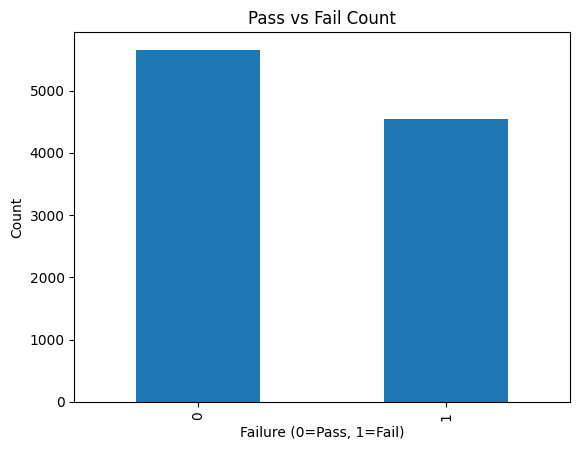

In [ ]:
#Pass vs Fail Count
plt.figure()
df['failures'].value_counts().plot(kind='bar')
plt.title('Pass vs Fail Count')
plt.xlabel('Failure (0=Pass, 1=Fail)')
plt.ylabel('Count')
plt.show()


In [ ]:
df.isnull().sum()

,0
G1,0
G2,0
G3,0
studytime,0
absences,0
failures,0
schoolsup,0
famsup,0
age,0
address,0


In [ ]:
df.to_csv("final_projectDS_powerbi.csv", index=False)

#Feature Engineering

In [ ]:
#Target Split
X = df.drop(columns=['G3'])
y = df['G3']

The final score (G3) is treated as a quantitative proxy for skill evolution, while prior assessments and behavioral attributes serve as predictive signals.

In [ ]:
#Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True,dtype=int)

In [ ]:
X.head()

,G1,G2,studytime,absences,failures,age,online_learning_hours,daily_study_hours,practice_sessions,screen_time_hours,...,health_Poor,learning_style_Kinesthetic,learning_style_Unknown,learning_style_Visual,motivation_level_Low,motivation_level_Medium,motivation_level_Unknown,parent_education_Primary,parent_education_Secondary,parent_education_Unknown
0,35,35,1,5,0,13,14,2,2,7,...,1,1,0,0,0,1,0,1,0,0
1,0,0,3,11,1,14,4,4,7,2,...,1,0,0,1,0,1,0,0,0,0
2,55,70,2,3,0,16,8,5,4,5,...,0,0,0,0,0,1,0,0,1,0
3,75,70,4,3,0,14,4,4,4,2,...,0,1,0,0,1,0,0,0,0,0
4,55,75,2,3,0,14,7,2,5,2,...,1,1,0,0,0,1,0,0,1,0


In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#Train–Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
#Baseline Model — Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

Linear Regression is employed as a baseline to establish a performance benchmark under linear assumptions.

In [ ]:
#Predict & evaluate
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R² Score:", lr_r2)
print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)


Linear Regression R² Score: 0.8628747899753185
Linear Regression MAE: 8.518945125697707
Linear Regression RMSE: 11.335015819804488


#INSIGHT

- The Linear Regression model was initially trained and tuned using regularization techniques, achieving an R² value of 0.8628, which indicates that it explains approximately 86.28% of the variation in student skill development.

- The obtained MAE of 8.52 and RMSE of 11.34 reflect a reasonable prediction accuracy for a tuned baseline regression model.

- Despite tuning, the Linear Regression model remains limited in capturing the non-linear nature of human learning behavior.

- Therefore, Random Forest Regression is employed as the primary model to better capture non-linear relationships among academic performance, study habits, and learning behaviors, leading to improved robustness and adaptability.

In [ ]:
#Ridge Regression (tuned Linear Regression)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train, y_train)

best_lr = grid_ridge.best_estimator_


In [ ]:
#Evaluate Tuned Linear Regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred_lr_tuned = best_lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr_tuned)
lr_mae = mean_absolute_error(y_test, y_pred_lr_tuned)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_tuned))

print("Tuned Linear Regression R²:", lr_r2)
print("Tuned Linear Regression MAE:", lr_mae)
print("Tuned Linear Regression RMSE:", lr_rmse)


Tuned Linear Regression R²: 0.862860937244196
Tuned Linear Regression MAE: 8.520721705168402
Tuned Linear Regression RMSE: 11.335588351146217


#INSIGHT

- The tuned Linear Regression model shows negligible change in performance compared to the baseline, with almost identical R², MAE, and RMSE values.

- This indicates that the original Linear Regression model was already well-optimized and that further performance gains are unlikely under linear assumptions, thereby motivating the use of Random Forest Regression to capture non-linear learning patterns.

In [ ]:
#Train & Evaluate Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
#Predict & Evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R² Score:", rf_r2)
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)


Random Forest R² Score: 0.913259506751616
Random Forest MAE: 7.201725490196079
Random Forest RMSE: 9.015180394702018


#INSIGHT

- The Random Forest Regression model achieved an R² score of 0.9133, demonstrating its ability to explain approximately 91.33% of the variance in student skill evolution.

- Compared to the tuned Linear Regression model, Random Forest significantly reduces the prediction error, with a MAE of 7.20 and an RMSE of 9.02, indicating more accurate and robust predictions.

- This improvement confirms that Random Forest effectively captures the non-linear learning patterns and complex feature interactions inherent in human learning behavior, making it the most suitable model for the proposed adaptive intelligence engine.

In [ ]:
#Feature Importance
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


,0
failures,0.731778
G2,0.181444
G1,0.013555
absences,0.009467
online_learning_hours,0.008455
practice_sessions,0.006843
screen_time_hours,0.006309
daily_study_hours,0.005586
age,0.005427
studytime,0.003961


In [ ]:
#top 10
feature_importance.head(10)

,0
failures,0.731778
G2,0.181444
G1,0.013555
absences,0.009467
online_learning_hours,0.008455
practice_sessions,0.006843
screen_time_hours,0.006309
daily_study_hours,0.005586
age,0.005427
studytime,0.003961


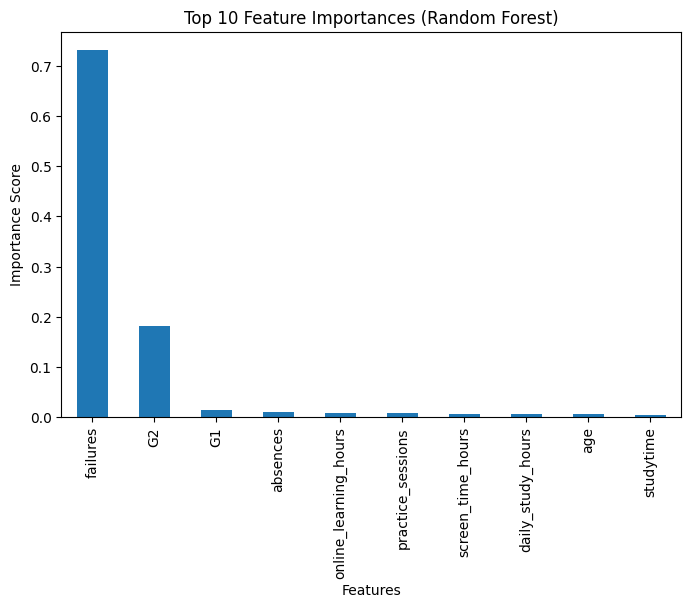

In [ ]:
#Plot Feature Importance
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.show()


#INSIGHT

- Feature importance analysis shows that **previous failures and prior academic scores (G2 and G1)** are the strongest predictors of student skill evolution.

- Behavioral factors such as absences and learning engagement contribute moderately, while demographic features have minimal impact, highlighting the dominance of academic history in predicting learning outcomes.



In [ ]:
#Save the Trained Model
import joblib

# Save model and scaler
joblib.dump(rf, "random_forest_skill_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


#PROJECT SUMMARY

- This project developed an Adaptive Intelligence Engine to predict human skill evolution in digital platforms using a structured data science pipeline.

- Data preprocessing, exploratory analysis, feature engineering, and regression-based modeling were performed. Linear Regression was tuned as a baseline model, followed by Random Forest Regression to capture non-linear learning patterns. Model evaluation confirmed improved predictive performance using Random Forest, supported by feature importance analysis.

#CONCLUSION

- The study demonstrates that machine learning techniques can effectively predict student skill evolution using academic and behavioral data.

- While Linear Regression provided a strong baseline, Random Forest Regression significantly improved prediction accuracy by modeling non-linear relationships.

- The results confirm that prior academic performance and failure history are key determinants of learning outcomes, validating the effectiveness of the proposed adaptive intelligence engine.

#FUTURE WORK

- Future work can extend this system by incorporating real-time interaction data, deep learning models, and personalized recommendation strategies.

- Integration with live digital learning platforms and adaptive feedback mechanisms can further enhance prediction accuracy and support individualized learning pathways.